# GSEA - MSigDB Hallmark

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np
import polars as pl

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Resolve this analysis folder (paper/01_rna) regardless of the kernel's cwd.
def _here():
    for c in (Path.cwd(), *Path.cwd().parents):
        if (c / '00_build_metadata.py').exists():
            return c
    raise RuntimeError('run this notebook from inside paper/01_rna')

DIR = _here()

GSEA_FILE = DIR / 'results' / 'gsea_msigdb_results.pq'   # <- 21_gsea_msigdb.py
META_FILE = DIR / 'data' / 'hallmark_metadata.tsv'      # hand-transcribed, vendored

LIBRARY = 'MSigDB_H'
CONTRASTS = ['DE_vs_ESC', 'HB_vs_DE', 'iHEP_vs_HB', 'mHEP_vs_iHEP']
CLABELS   = ['ESC→DE', 'DE→HB', 'HB→iHEP', 'iHEP→mHEP']
ROW_THRESH = 0.05   # include a set if FDR < this in >=1 transition

# Process categories in figure row order (paper's verbatim lowercase labels)
CAT_ORDER = ['proliferation', 'DNA damage', 'signaling', 'pathway',
             'metabolic', 'immune', 'development', 'cellular component']

# Single diverging colormap: scalar = sign(NES) * -log10(FDR)
CMAP  = plt.get_cmap('PuOr_r')
CNORM = Normalize(-3.0, 3.0)

def signed_sig(nes, fdr):
    return np.sign(nes) * min(-np.log10(max(fdr, 1e-3)), 3.0)

## Load data

In [3]:
meta = pl.read_csv(META_FILE, separator='\t')
HALLMARK_CATEGORY = dict(zip(meta['hallmark'].to_list(), meta['category'].to_list()))
DISPLAY = dict(zip(meta['hallmark'].to_list(), meta['display_name'].to_list()))

df = pl.read_parquet(GSEA_FILE).with_columns([
    pl.col('NES').cast(float),
    pl.col('FDR q-val').cast(float).alias('fdr'),
])
k = df.filter((pl.col('library') == LIBRARY) & pl.col('contrast').is_in(CONTRASTS))
terms = sorted(k['Term'].unique().to_list())
cidx = {c: j for j, c in enumerate(CONTRASTS)}
nes = np.full((len(terms), 4), np.nan)
fdr = np.full((len(terms), 4), np.nan)
for row in k.iter_rows(named=True):
    i = terms.index(row['Term']); j = cidx[row['contrast']]
    nes[i, j] = row['NES']; fdr[i, j] = row['fdr']

recs = []
for i in range(len(terms)):
    if not (np.nansum(fdr[i] < ROW_THRESH) >= 1):
        continue
    cat = HALLMARK_CATEGORY.get(terms[i], '(unmapped)')
    peak_j = int(np.nanargmax(np.abs(nes[i])))
    recs.append({'i': i, 'term': terms[i], 'category': cat,
                 'peak_j': peak_j, 'peak_nes': float(nes[i, peak_j])})

crank = lambda c: CAT_ORDER.index(c) if c in CAT_ORDER else len(CAT_ORDER)
recs.sort(key=lambda r: (crank(r['category']), r['peak_j'], -r['peak_nes']))
n = len(recs)

cat_bounds = [0]
for j in range(1, n):
    if recs[j]['category'] != recs[j - 1]['category']:
        cat_bounds.append(j)
cat_bounds.append(n)
cat_spans = [(cat_bounds[t], cat_bounds[t + 1], recs[cat_bounds[t]]['category'])
             for t in range(len(cat_bounds) - 1)]
print(f'{n} Hallmark sets (FDR<{ROW_THRESH} in >=1 transition)')

46 Hallmark sets (FDR<0.05 in >=1 transition)


## Plot

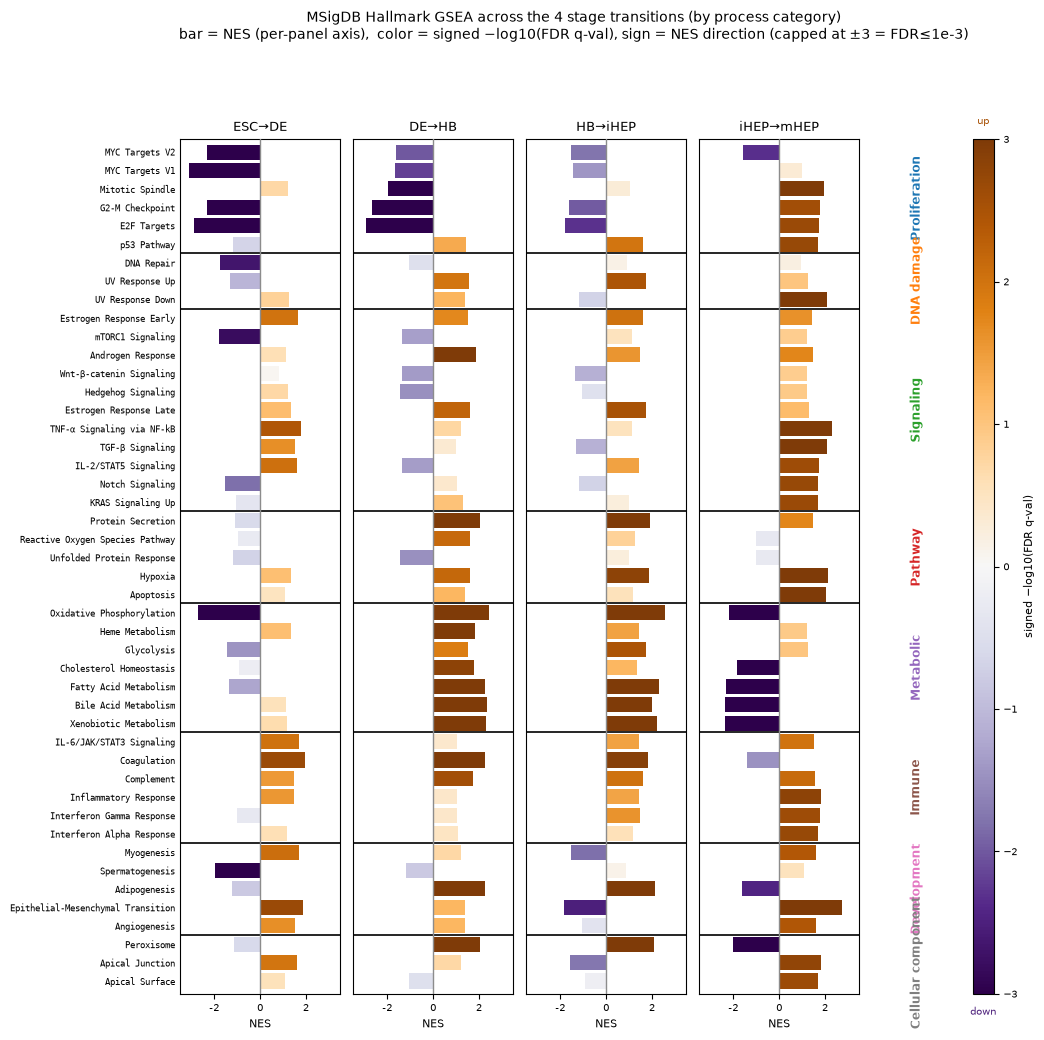

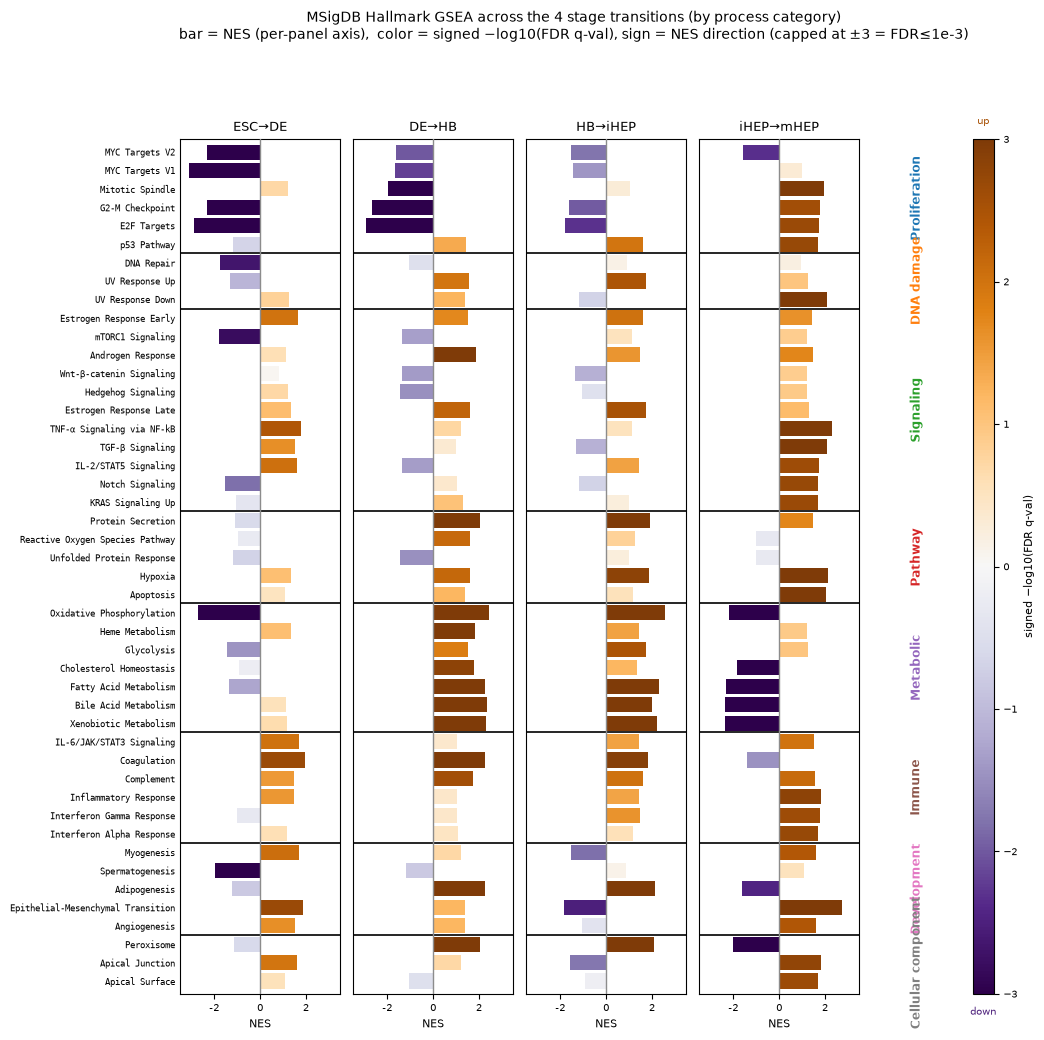

In [4]:
mx = float(np.nanmax(np.abs(nes[[r['i'] for r in recs]])))
xmax = max(2.5, np.ceil(mx * 2) / 2)
xticks = [-2, 0, 2]

fig = plt.figure(figsize=(10.5, max(5, 0.20 * n + 1.9)))
gs = fig.add_gridspec(1, 6, width_ratios=[1, 1, 1, 1, 0.55, 0.13], wspace=0.10)
axes = []
for j in range(4):
    axj = fig.add_subplot(gs[0, j], sharey=(axes[0] if axes else None))
    axes.append(axj)
ax_cat = fig.add_subplot(gs[0, 4])
ax_cb = fig.add_subplot(gs[0, 5])

for j, axj in enumerate(axes):
    axj.axvline(0, color='0.55', lw=1, zorder=4)
    for r_i, r in enumerate(recs):
        i = r['i']
        if np.isnan(nes[i, j]):
            continue
        axj.barh(r_i, width=nes[i, j], left=0, height=0.82,
                 color=CMAP(CNORM(signed_sig(nes[i, j], fdr[i, j]))),
                 edgecolor='none', zorder=3)
    axj.set_xlim(-xmax, xmax)
    axj.set_ylim(-0.7, n - 0.3)
    axj.invert_yaxis()
    axj.set_title(CLABELS[j], fontsize=9)
    axj.set_xticks(xticks)
    axj.set_xticklabels([str(t) for t in xticks], fontsize=7)
    axj.set_xlabel('NES', fontsize=8)
    axj.tick_params(axis='y', length=0)
    for b in cat_bounds[1:-1]:
        axj.axhline(b - 0.5, color='black', lw=1.2)
    if j == 0:
        axj.set_yticks(range(n))
        axj.set_yticklabels([DISPLAY.get(r['term'], r['term']) for r in recs],
                            fontsize=6.5, family='monospace')
    else:
        axj.tick_params(labelleft=False)

# process-category labels (right, between the panels and the colorbar)
ax_cat.set_xlim(0, 1); ax_cat.set_ylim(-0.7, n - 0.3)
ax_cat.invert_yaxis(); ax_cat.axis('off')
cmap_cat = plt.get_cmap('tab10')
for ci, (a, b, name) in enumerate(cat_spans):
    mid = (a + b - 1) / 2
    ax_cat.text(0.5, mid, name[0].upper() + name[1:], ha='center', va='center',
                rotation=90, fontsize=8.5, fontweight='bold', color=cmap_cat(ci % 10))

# single diverging colorbar in true units: signed -log10(FDR)
cb = fig.colorbar(ScalarMappable(norm=CNORM, cmap=CMAP), cax=ax_cb)
cb.set_ticks([-3, -2, -1, 0, 1, 2, 3])
cb.set_ticklabels(['−3', '−2', '−1', '0', '1', '2', '3'], fontsize=7)
cb.set_label('signed −log10(FDR q-val)', fontsize=8)
ax_cb.text(0.5, 1.015, 'up', transform=ax_cb.transAxes, ha='center',
           va='bottom', fontsize=7, color=CMAP(0.92))
ax_cb.text(0.5, -0.015, 'down', transform=ax_cb.transAxes, ha='center',
           va='top', fontsize=7, color=CMAP(0.08))

fig.suptitle(
    'MSigDB Hallmark GSEA across the 4 stage transitions (by process category)\n'
    'bar = NES (per-panel axis),  color = signed −log10(FDR q-val), sign = NES '
    'direction (capped at ±3 = FDR≤1e-3)',
    fontsize=10, y=0.997)
fig

In [5]:
FIG_NAME = 'hallmark_nes_bars'
fig.savefig(DIR / 'figs' / f"{FIG_NAME}.png", dpi=200, bbox_inches="tight")
fig.savefig(DIR / 'figs' / f"{FIG_NAME}.pdf", bbox_inches="tight")